In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from utils.dataset_loader import mimic_loader
from utils.microbiology_result_labeling import classify_culture_result

root = "ADS599-Capstone/raw_data"

df = mimic_loader(path=root, name='microbiology_events')

In [2]:
print(f"Unique Patients: {df['subject_id'].nunique()}")
print(f"Unique ED Stays: {df['ed_stay_id'].nunique()}")
print(f"Unique Hospital Stays: {df['hadm_id'].nunique()}")

Unique Patients: 96961
Unique ED Stays: 174901
Unique Hospital Stays: 122671


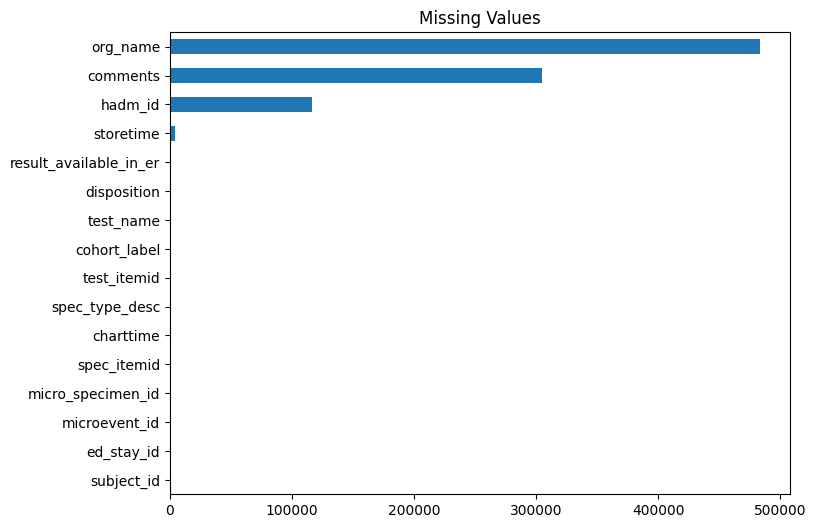

In [8]:
missing_values = df.isna().sum()
missing_values.sort_values().plot(kind='barh', figsize = (8,6), title='Missing Values')
plt.show()

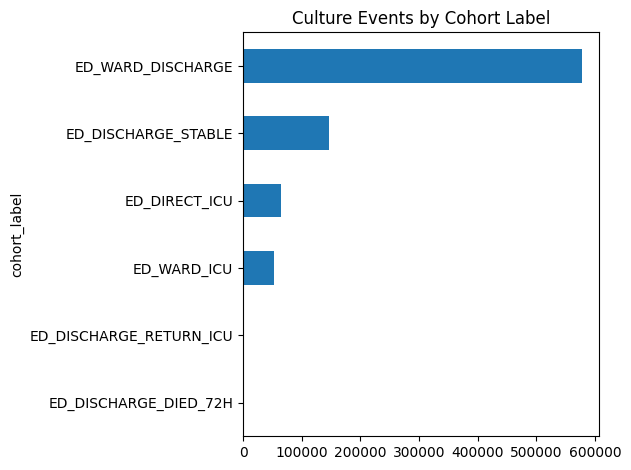

In [13]:
df.value_counts('cohort_label').sort_values().plot(kind='barh', title='Culture Events by Cohort Label')
plt.tight_layout()
plt.show()
# Distribution of culture records across patient pathway labels

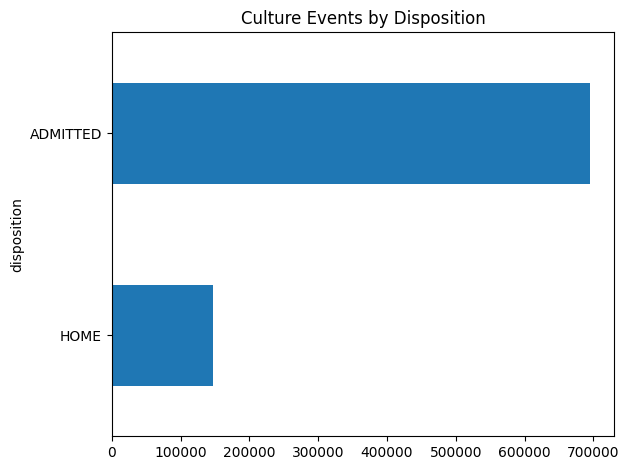

In [14]:
df.value_counts('disposition').sort_values().plot(kind='barh', title='Culture Events by Disposition')
plt.tight_layout()
plt.show()
# Split between admitted patients and those discharged home

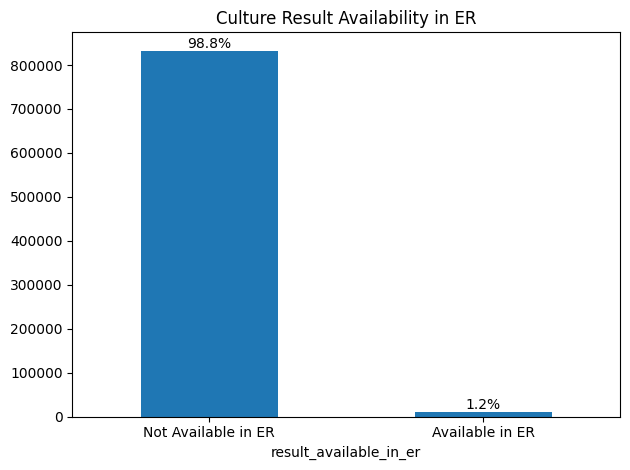

In [15]:
result_counts = df['result_available_in_er'].value_counts().rename({0: 'Not Available in ER', 1: 'Available in ER'})
ax = result_counts.plot(kind='bar', title='Culture Result Availability in ER')
total = result_counts.sum()
for p in ax.patches:
    ax.annotate(f'{p.get_height()/total:.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# The vast majority of culture results are not back before the patient leaves the ER

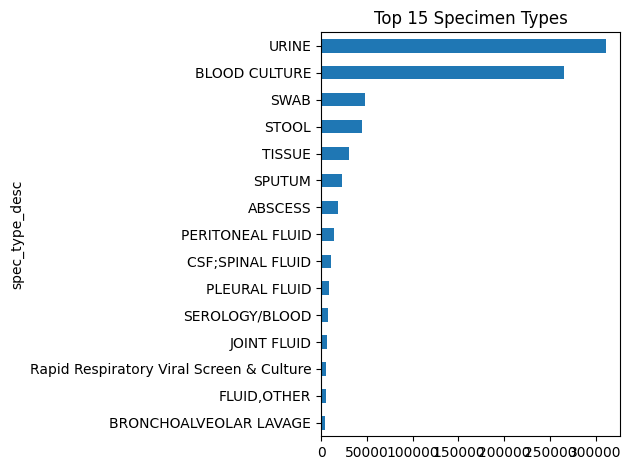

In [16]:
df.value_counts('spec_type_desc').head(15).sort_values().plot(kind='barh', title='Top 15 Specimen Types')
plt.tight_layout()
plt.show()
# Most common specimen types collected — blood and urine dominate

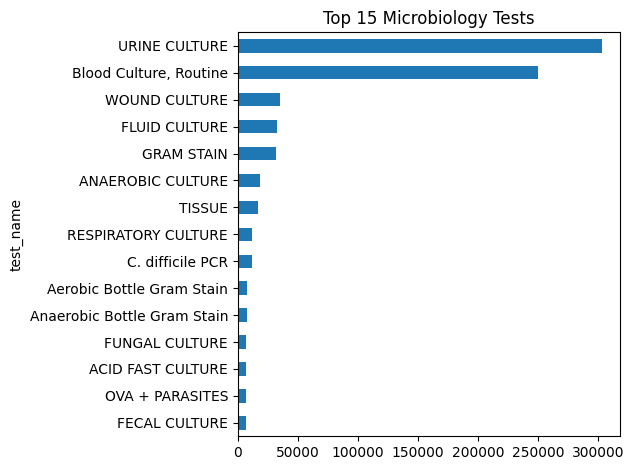

In [17]:
df.value_counts('test_name').head(15).sort_values().plot(kind='barh', title='Top 15 Microbiology Tests')
plt.tight_layout()
plt.show()
# Most frequently ordered micro tests — shows which cultures are most common in this cohort

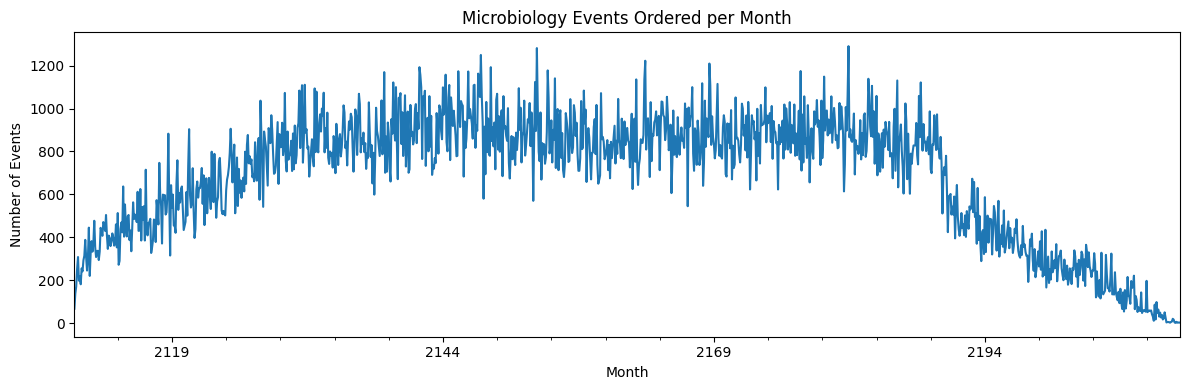

In [18]:
events_by_month = (
    df.assign(charttime=pd.to_datetime(df['charttime']))
    .set_index('charttime')
    .resample('ME')
    .size()
)
events_by_month.plot(kind='line', title='Microbiology Events Ordered per Month', figsize=(12, 4))
plt.xlabel('Month')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()
# Volume of culture orders over time — useful for spotting data gaps or collection artifacts

# Condense records for action space

In [5]:
df.head()

,subject_id,hadm_id,ed_stay_id,microevent_id,micro_specimen_id,charttime,spec_itemid,spec_type_desc,test_itemid,test_name,org_name,comments,storetime,result_available_in_er,disposition,cohort_label
0,10000032,29079034.0,32952584,29,9682545,2180-07-23 06:39:00,70012,BLOOD CULTURE,90201,"Blood Culture, Routine",NaN,NO GROWTH.,2180-07-29 07:37:00,0,HOME,ED_DISCHARGE_RETURN_ICU
1,10000032,29079034.0,32952584,30,9150362,2180-07-23 06:50:00,70079,URINE,90039,URINE CULTURE,NaN,"<10,000 organisms/ml.",2180-07-24 11:53:00,0,HOME,ED_DISCHARGE_RETURN_ICU
2,10000032,22595853.0,33258284,13,5674338,2180-05-06 22:25:00,70012,BLOOD CULTURE,90201,"Blood Culture, Routine",NaN,NO GROWTH.,2180-05-12 08:07:00,0,ADMITTED,ED_WARD_DISCHARGE
3,10000032,22595853.0,33258284,14,1758637,2180-05-07 00:10:00,70079,URINE,90039,URINE CULTURE,NaN,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO...",2180-05-08 11:12:00,0,ADMITTED,ED_WARD_DISCHARGE
4,10000032,22595853.0,33258284,15,8440864,2180-05-07 00:19:00,70070,SWAB,90115,R/O VANCOMYCIN RESISTANT ENTEROCOCCUS,NaN,No VRE isolated.,2180-05-09 07:57:00,0,ADMITTED,ED_WARD_DISCHARGE


In [8]:
df.value_counts('ed_stay_id')

ed_stay_id
36822632    248
31216139    217
33692286    212
37326350    185
35093590    157
           ... 
34983932      1
32922923      1
32929951      1
35418763      1
36370988      1
Name: count, Length: 174901, dtype: int64

In [13]:
df.value_counts('spec_type_desc').head(20)

spec_type_desc
URINE                                       311172
BLOOD CULTURE                               265587
SWAB                                         47998
STOOL                                        44547
TISSUE                                       30309
SPUTUM                                       22471
ABSCESS                                      18795
PERITONEAL FLUID                             14652
CSF;SPINAL FLUID                             10967
PLEURAL FLUID                                 8600
SEROLOGY/BLOOD                                7863
JOINT FLUID                                   6523
Rapid Respiratory Viral Screen & Culture      5281
FLUID,OTHER                                   5126
BRONCHOALVEOLAR LAVAGE                        4385
Blood (EBV)                                   4130
BILE                                          3778
MRSA SCREEN                                   3179
Blood (CMV AB)                                2634
IMMUNOLOGY      

Consecutive culture order time gaps (n=232,770 pairs):
            count  pct (%)
gap_min                   
<15 min     37072     15.9
15-30 min   17503      7.5
30-60 min   18789      8.1
1-2 hrs     26423     11.4
2-4 hrs     28680     12.3
>4 hrs     104303     44.8

Within 15 min: 15.9%
Within 30 min: 23.4%
Within 60 min: 31.5%


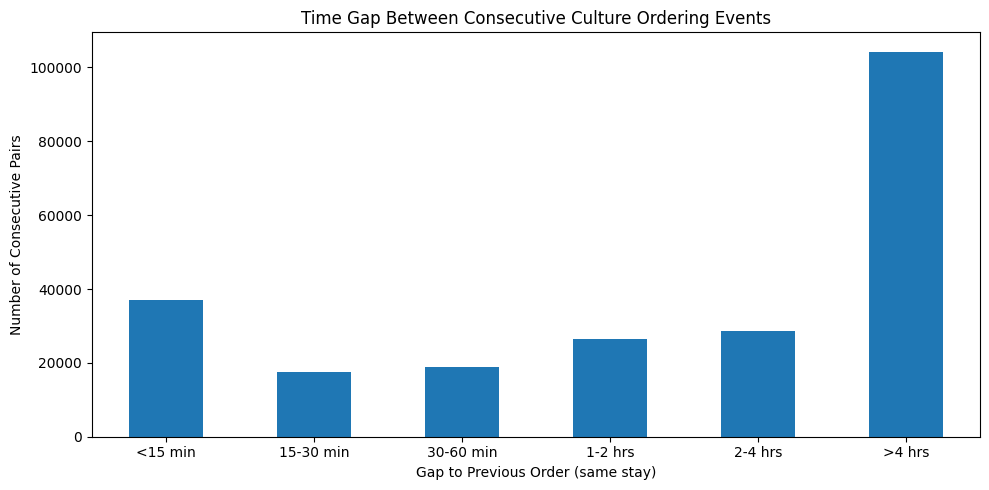

In [14]:
# Time gap between consecutive culture ordering events within the same stay
charttimes = (
    df[['ed_stay_id', 'charttime']]
    .drop_duplicates()
    .sort_values(['ed_stay_id', 'charttime'])
)

charttimes['gap_min'] = (
    charttimes.groupby('ed_stay_id')['charttime']
    .diff()
    .dt.total_seconds()
    .div(60)
)

gaps = charttimes['gap_min'].dropna()

bins = [0, 15, 30, 60, 120, 240, float('inf')]
labels = ['<15 min', '15-30 min', '30-60 min', '1-2 hrs', '2-4 hrs', '>4 hrs']
gap_buckets = pd.cut(gaps, bins=bins, labels=labels)
gap_dist = gap_buckets.value_counts().sort_index()
gap_pct = (gap_dist / gap_dist.sum() * 100).round(1)

print(f"Consecutive culture order time gaps (n={len(gaps):,} pairs):")
print(pd.DataFrame({'count': gap_dist, 'pct (%)': gap_pct}))
print(f"\nWithin 15 min: {gap_pct['<15 min']:.1f}%")
print(f"Within 30 min: {gap_pct[['<15 min', '15-30 min']].sum():.1f}%")
print(f"Within 60 min: {gap_pct[['<15 min', '15-30 min', '30-60 min']].sum():.1f}%")

gap_dist.plot(kind='bar', title='Time Gap Between Consecutive Culture Ordering Events', figsize=(10, 5))
plt.xlabel('Gap to Previous Order (same stay)')
plt.ylabel('Number of Consecutive Pairs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Distribution of gaps between successive culture batches — helps determine window for grouping simultaneous orders

In [19]:
charttimes

,ed_stay_id,charttime,gap_min
143151,30000012,2126-02-14 22:15:00,NaN
143152,30000012,2126-02-14 22:20:00,5.0
143153,30000012,2126-02-14 22:58:00,38.0
143154,30000012,2126-02-15 13:25:00,867.0
323030,30000038,2152-12-07 18:13:00,NaN
...,...,...,...
12965,39999863,2122-01-17 07:25:00,690.0
109040,39999961,2145-05-16 19:47:00,NaN
109041,39999961,2145-05-16 20:15:00,28.0
109042,39999961,2145-05-16 20:30:00,15.0


In [34]:
df[(df['subject_id'] == 10000032) & (df['ed_stay_id'] == 38112554)].sort_values(by='storetime')

,subject_id,hadm_id,ed_stay_id,microevent_id,micro_specimen_id,charttime,spec_itemid,spec_type_desc,test_itemid,test_name,org_name,comments,storetime,result_available_in_er,disposition,cohort_label
19,10000032,22841357.0,38112554,24,295483,2180-06-26 19:00:00,70053,PERITONEAL FLUID,90270,GRAM STAIN,NaN,1+ (<1 per 1000X FIELD): POLYMORPHONUCLEA...,2180-06-26 21:53:00,0,ADMITTED,ED_WARD_DISCHARGE
20,10000032,22841357.0,38112554,27,6172181,2180-06-26 22:39:00,70079,URINE,90039,URINE CULTURE,NaN,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO...",2180-06-28 11:51:00,0,ADMITTED,ED_WARD_DISCHARGE
18,10000032,22841357.0,38112554,25,295483,2180-06-26 19:00:00,70053,PERITONEAL FLUID,90268,FLUID CULTURE,NaN,NO GROWTH.,2180-06-29 09:05:00,0,ADMITTED,ED_WARD_DISCHARGE
21,10000032,22841357.0,38112554,28,2391447,2180-06-26 22:45:00,70070,SWAB,90115,R/O VANCOMYCIN RESISTANT ENTEROCOCCUS,NaN,No VRE isolated.,2180-06-29 10:47:00,0,ADMITTED,ED_WARD_DISCHARGE
13,10000032,22841357.0,38112554,20,159861,2180-06-26 18:30:00,70079,URINE,90039,URINE CULTURE,ENTEROCOCCUS SP.,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO...",2180-06-29 14:32:00,0,ADMITTED,ED_WARD_DISCHARGE
14,10000032,22841357.0,38112554,21,159861,2180-06-26 18:30:00,70079,URINE,90039,URINE CULTURE,ENTEROCOCCUS SP.,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO...",2180-06-29 14:32:00,0,ADMITTED,ED_WARD_DISCHARGE
15,10000032,22841357.0,38112554,22,159861,2180-06-26 18:30:00,70079,URINE,90039,URINE CULTURE,ENTEROCOCCUS SP.,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO...",2180-06-29 14:32:00,0,ADMITTED,ED_WARD_DISCHARGE
16,10000032,22841357.0,38112554,23,159861,2180-06-26 18:30:00,70079,URINE,90039,URINE CULTURE,ENTEROCOCCUS SP.,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO...",2180-06-29 14:32:00,0,ADMITTED,ED_WARD_DISCHARGE
12,10000032,22841357.0,38112554,19,8207206,2180-06-26 18:15:00,70012,BLOOD CULTURE,90201,"Blood Culture, Routine",NaN,NO GROWTH.,2180-07-02 07:27:00,0,ADMITTED,ED_WARD_DISCHARGE
17,10000032,22841357.0,38112554,26,295483,2180-06-26 19:00:00,70053,PERITONEAL FLUID,90245,ANAEROBIC CULTURE,NaN,NO GROWTH.,2180-07-02 14:28:00,0,ADMITTED,ED_WARD_DISCHARGE


=== OVERALL RESULT LATENCY (hrs) ===
count    838411.0
mean         87.8
std         125.1
min           0.1
25%          33.8
50%          65.7
75%         130.3
90%         145.2
95%         153.6
max       15779.6
Name: result_latency_hrs, dtype: float64

=== MEDIAN LATENCY BY SPECIMEN TYPE (top 10) ===
spec_type_desc
BLOOD CULTURE       133.8
TISSUE               94.9
ABSCESS              92.7
PERITONEAL FLUID     73.9
PLEURAL FLUID        72.5
SWAB                 69.3
CSF;SPINAL FLUID     66.3
URINE                44.9
STOOL                40.4
SPUTUM               21.2


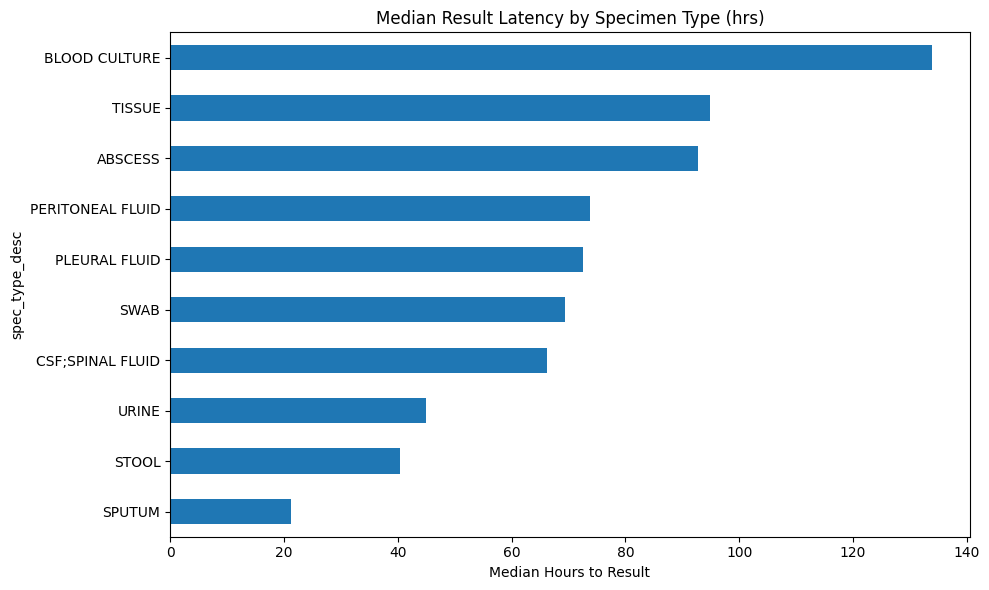

In [2]:
# How long do culture results take to come back?
tmp = df.assign(
    charttime=pd.to_datetime(df['charttime']),
    storetime=pd.to_datetime(df['storetime'])
)
tmp['result_latency_hrs'] = (tmp['storetime'] - tmp['charttime']).dt.total_seconds() / 3600
latency = tmp.dropna(subset=['result_latency_hrs']).query('result_latency_hrs >= 0')

print("=== OVERALL RESULT LATENCY (hrs) ===")
print(latency['result_latency_hrs'].describe(percentiles=[.25, .5, .75, .90, .95]).round(1))

print("\n=== MEDIAN LATENCY BY SPECIMEN TYPE (top 10) ===")
top_specs = df['spec_type_desc'].value_counts().head(10).index
print(
    latency[latency['spec_type_desc'].isin(top_specs)]
    .groupby('spec_type_desc')['result_latency_hrs']
    .median()
    .sort_values(ascending=False)
    .round(1)
    .to_string()
)

# Bar chart: median latency by top specimen type
(
    latency[latency['spec_type_desc'].isin(top_specs)]
    .groupby('spec_type_desc')['result_latency_hrs']
    .median()
    .sort_values()
    .plot(kind='barh', figsize=(10, 6), title='Median Result Latency by Specimen Type (hrs)')
)
plt.xlabel('Median Hours to Result')
plt.tight_layout()
plt.show()
# Blood cultures dominate by volume and have the longest latency — their results
# almost never come back during the ED visit, making them retrospective labels

Subsequent ordering events analyzed: 232,770
Events where ≥1 prior culture still pending: 96.6%
Events where ALL prior cultures still pending: 64.5%

=== % OF PRIOR CULTURES PENDING AT TIME OF NEXT ORDER ===
count    232770.0
mean         83.6
std          28.3
min           0.0
25%          75.0
50%         100.0
75%         100.0
90%         100.0
max         100.0
Name: pct_pending, dtype: float64


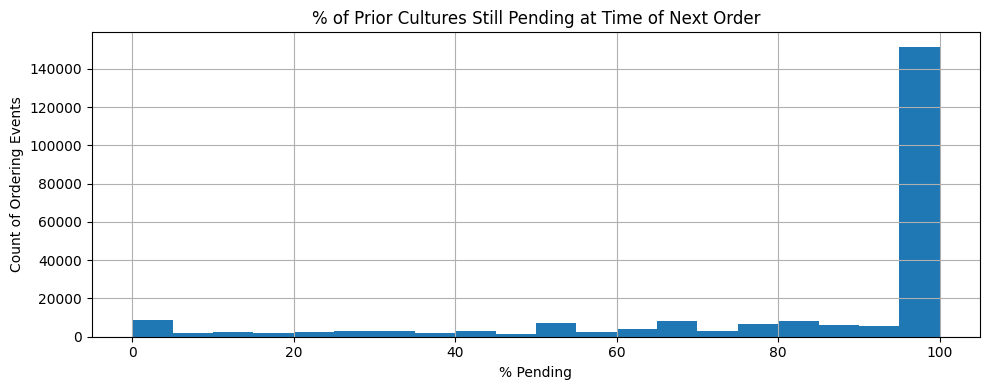

In [3]:
# At the time of each subsequent ordering event, how many prior cultures are still pending?
# "Pending" = storetime is null or storetime > current order_time

events = tmp[['ed_stay_id', 'charttime', 'storetime']].copy()

# Unique ordering moments per stay, ranked
order_times = (
    events[['ed_stay_id', 'charttime']]
    .drop_duplicates()
    .sort_values(['ed_stay_id', 'charttime'])
)
order_times['order_rank'] = order_times.groupby('ed_stay_id').cumcount() + 1

# Only care about 2nd+ ordering events (there must be a prior to be pending)
subsequent = (
    order_times[order_times['order_rank'] >= 2]
    [['ed_stay_id', 'charttime']]
    .rename(columns={'charttime': 'order_time'})
)

# Join all prior culture records from the same stay
merged = subsequent.merge(events, on='ed_stay_id')
merged = merged[merged['charttime'] < merged['order_time']]
merged['is_pending'] = merged['storetime'].isna() | (merged['storetime'] > merged['order_time'])

pending = (
    merged.groupby(['ed_stay_id', 'order_time'])
    .agg(n_prior=('charttime', 'count'), n_pending=('is_pending', 'sum'))
    .reset_index()
)
pending['pct_pending'] = pending['n_pending'] / pending['n_prior'] * 100

print(f"Subsequent ordering events analyzed: {len(pending):,}")
print(f"Events where ≥1 prior culture still pending: {(pending['n_pending'] > 0).mean():.1%}")
print(f"Events where ALL prior cultures still pending: {(pending['n_pending'] == pending['n_prior']).mean():.1%}")
print("\n=== % OF PRIOR CULTURES PENDING AT TIME OF NEXT ORDER ===")
print(pending['pct_pending'].describe(percentiles=[.25, .5, .75, .90]).round(1))

pending['pct_pending'].clip(upper=100).hist(bins=20, figsize=(10, 4))
plt.title('% of Prior Cultures Still Pending at Time of Next Order')
plt.xlabel('% Pending')
plt.ylabel('Count of Ordering Events')
plt.tight_layout()
plt.show()
# High % pending means new ordering decisions are made before prior results are back —
# this is the key complexity for the action space: the agent can't wait for results

regex pattern to capture positives and negatives from org_name and comments and create flag column.  Need to remove records where storetime is after the end of the patients stay window.  Then I need to see how the charttime and storetimes are staggered

In [24]:
from utils.dataset_loader import mimic_loader

# Load cohort timing columns to compute stay window end per patient
cohort_timing = (
    mimic_loader(path=root, name='cohort_base')
    [['ed_stay_id', 'ed_outtime', 'dischtime', 'first_icu_intime']]
    .assign(
        ed_outtime=lambda x: pd.to_datetime(x['ed_outtime']),
        dischtime=lambda x: pd.to_datetime(x['dischtime']),
        first_icu_intime=lambda x: pd.to_datetime(x['first_icu_intime'])
    )
)

# Stay window end: ICU intime (if ICU), then dischtime (if admitted), then ed_outtime (ED-only)
cohort_timing['stay_window_end'] = (
    cohort_timing['first_icu_intime']
    .fillna(cohort_timing['dischtime'])
    .fillna(cohort_timing['ed_outtime'])
)

# Join stay_window_end onto microbiology
micro = df.copy()
micro['storetime'] = pd.to_datetime(micro['storetime'])
micro = micro.merge(cohort_timing[['ed_stay_id', 'stay_window_end']], on='ed_stay_id', how='left')

# Drop records where result came back after the patient's stay window ended
before = len(micro)
micro = micro[micro['storetime'].isna() | (micro['storetime'] <= micro['stay_window_end'])]
after = len(micro)
print(f"Dropped: {before - after:,} rows where storetime > stay_window_end ({(before - after) / before:.1%})")
print(f"Remaining: {after:,} rows")

# Create action_space column: top 20 spec_type_desc values, rest → 'OTHER'
top_20_specs = df['spec_type_desc'].value_counts().head(20).index
micro['action_space'] = micro['spec_type_desc'].where(
    micro['spec_type_desc'].isin(top_20_specs), other='OTHER'
)

coverage = micro[micro['action_space'] != 'OTHER'].shape[0] / len(micro)
print(f"\nTop 20 spec types cover {coverage:.1%} of remaining records")
print(f"\naction_space value counts:")
print(micro['action_space'].value_counts())

cohort/base-00000-of-00001.parquet:   0%|          | 0.00/20.7M [00:00<?, ?B/s]

Generating base split:   0%|          | 0/399573 [00:00<?, ? examples/s]

Dropped: 447,222 rows where storetime > stay_window_end (53.1%)
Remaining: 395,389 rows

Top 20 spec types cover 96.8% of remaining records

action_space value counts:
action_space
URINE                                       144429
BLOOD CULTURE                                84684
STOOL                                        31950
SWAB                                         25474
TISSUE                                       20433
SPUTUM                                       16721
OTHER                                        12651
ABSCESS                                      10107
PERITONEAL FLUID                              8967
CSF;SPINAL FLUID                              5414
PLEURAL FLUID                                 5363
SEROLOGY/BLOOD                                5268
Rapid Respiratory Viral Screen & Culture      4148
JOINT FLUID                                   4071
FLUID,OTHER                                   2877
Blood (EBV)                                   2630
BRO

In [ ]:
micro['culture_result'] = micro.apply(
    lambda r: classify_culture_result(r['org_name'], r['comments']), axis=1
)

print(micro['culture_result'].value_counts())
print()
print(micro['culture_result'].value_counts(normalize=True).mul(100).round(1))

culture_result
POSITIVE     194143
NEGATIVE     170911
OTHER         19665
CANCELLED     10670
Name: count, dtype: int64

culture_result
POSITIVE     49.1
NEGATIVE     43.2
OTHER         5.0
CANCELLED     2.7
Name: proportion, dtype: float64


In [71]:
RESULT_PRIORITY = {'POSITIVE': 0, 'NEGATIVE': 1, 'CANCELLED': 2, 'OTHER': 3}

def worst_case_result(series):
    mapped = series.map(RESULT_PRIORITY)
    return series.iloc[mapped.argmin()]

micro_collapsed = (
    micro.groupby(['ed_stay_id', 'charttime', 'action_space'], observed=True)
    .agg(
        subject_id=('subject_id', 'first'),
        hadm_id=('hadm_id', 'first'),
        storetime=('storetime', 'max'),
        culture_result=('culture_result', worst_case_result)
    )
    .reset_index()
    [['subject_id', 'ed_stay_id', 'hadm_id', 'charttime', 'storetime', 'action_space', 'culture_result']]
)

print(f"Before: {len(micro):,} rows")
print(f"After:  {len(micro_collapsed):,} rows")
print(f"\naction_space value counts:")
print(micro_collapsed['action_space'].value_counts())
print(f"\nculture_result value counts:")
print(micro_collapsed['culture_result'].value_counts())
print(f"\nculture_result %:")
print(micro_collapsed['culture_result'].value_counts(normalize=True).mul(100).round(1))

Before: 395,389 rows
After:  186,172 rows

action_space value counts:
action_space
URINE                                       66020
BLOOD CULTURE                               56924
STOOL                                       14511
SPUTUM                                       6826
OTHER                                        6128
SWAB                                         6046
SEROLOGY/BLOOD                               4614
PERITONEAL FLUID                             3819
TISSUE                                       3387
CSF;SPINAL FLUID                             3148
Rapid Respiratory Viral Screen & Culture     2291
MRSA SCREEN                                  2115
ABSCESS                                      2019
PLEURAL FLUID                                1904
JOINT FLUID                                  1688
IMMUNOLOGY                                   1260
Blood (CMV AB)                                966
Blood (EBV)                                   892
FLUID,OTHER      